---

### 🎓 **Professor**: Apostolos Filippas

### 📘 **Class**: AI Engineering

### 📋 **Homework 6**: Multimodal Image Search

### 📅 **Due Date**: Day of Lecture 9, 11:59 PM

### Difficulty: ★★★★☆

**Note**: You are not allowed to share the contents of this notebook with anyone outside this class without written permission by the professor.

---

### Instructions

1. Use any external resource or collaborate with your classmates. But you have to cite external resources you've used and mention classmates you've collaborated with.
2. Run all cells before submitting to ensure they work.
3. Some tasks involve LLM API calls that cost money. Budget wisely.
4. I suggest you save intermediate results (descriptions, metadata) to a `temp/` folder so that you don't re-run expensive API calls.

## 1. Setup & Explore

The `../data/dogs/` directory contains dog images.
- These include different breeds, artistic styles (photographs, sketches, paintings, cartoons), settings, and some images with text or unusual content.

### Load and display images

Load all `.png` file paths from `../data/dogs/`, sorted by name. 
- Explore the data
- How many images are there? Are they AI generated? What type of variety do you observe? What breeds do you see? What artistic styles? Any images that look unusual or have text?

In [5]:
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

IMAGE_DIR = Path("data/dogs")
image_paths = sorted(IMAGE_DIR.glob("*.png"))

print(f"Total images: {len(image_paths)}")
for p in image_paths[:10]:
    print(" ", p.name)

Total images: 100
  dog_001.png
  dog_002.png
  dog_003.png
  dog_004.png
  dog_005.png
  dog_006.png
  dog_007.png
  dog_008.png
  dog_009.png
  dog_010.png


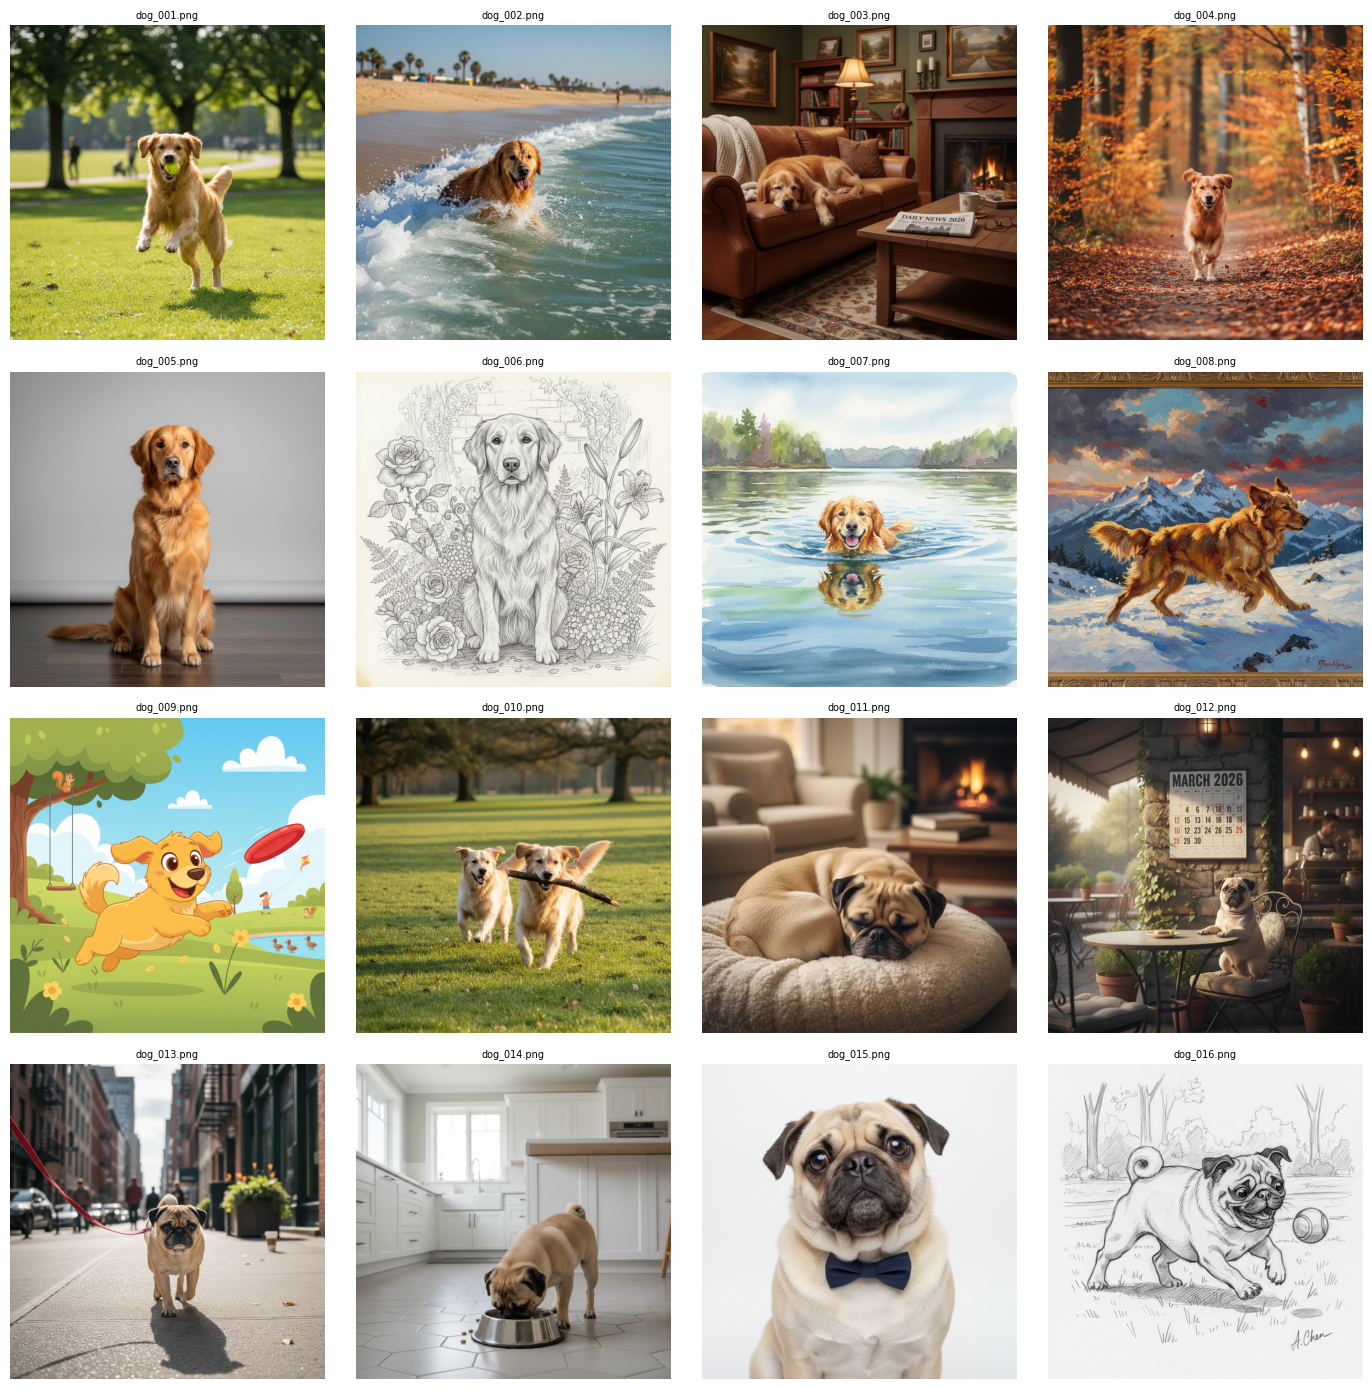

In [6]:
sample = image_paths[:16]
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for ax, img_path in zip(axes.flat, sample):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [10]:
print(os.listdir("data/dogs"))

['dog_027.png', 'dog_033.png', 'dog_032.png', 'dog_026.png', 'dog_018.png', 'dog_030.png', 'dog_024.png', 'dog_025.png', 'dog_031.png', 'dog_019.png', 'dog_035.png', 'dog_021.png', 'dog_009.png', 'dog_008.png', 'dog_020.png', 'dog_034.png', 'dog_022.png', 'dog_036.png', 'dog_037.png', 'dog_023.png', 'dog_087.png', 'dog_093.png', 'dog_078.png', 'dog_044.png', 'dog_050.png', 'dog_051.png', 'dog_045.png', 'dog_079.png', 'dog_092.png', 'dog_086.png', 'dog_090.png', 'dog_084.png', 'dog_053.png', 'dog_047.png', 'dog_046.png', 'dog_052.png', 'dog_085.png', 'dog_091.png', 'dog_095.png', 'dog_081.png', 'dog_056.png', 'dog_042.png', 'dog_043.png', 'dog_057.png', 'dog_080.png', 'dog_094.png', 'dog_082.png', 'dog_096.png', 'dog_041.png', 'dog_055.png', 'dog_069.png', 'dog_068.png', 'dog_054.png', 'dog_040.png', 'dog_097.png', 'dog_083.png', 'dog_059.png', 'dog_065.png', 'dog_071.png', 'dog_070.png', 'dog_064.png', 'dog_058.png', 'dog_099.png', 'dog_072.png', 'dog_066.png', 'dog_067.png', 'dog_073.

Total images: 100
  dog_001.png
  dog_002.png
  dog_003.png
  dog_004.png
  dog_005.png
  dog_006.png
  dog_007.png
  dog_008.png
  dog_009.png
  dog_010.png


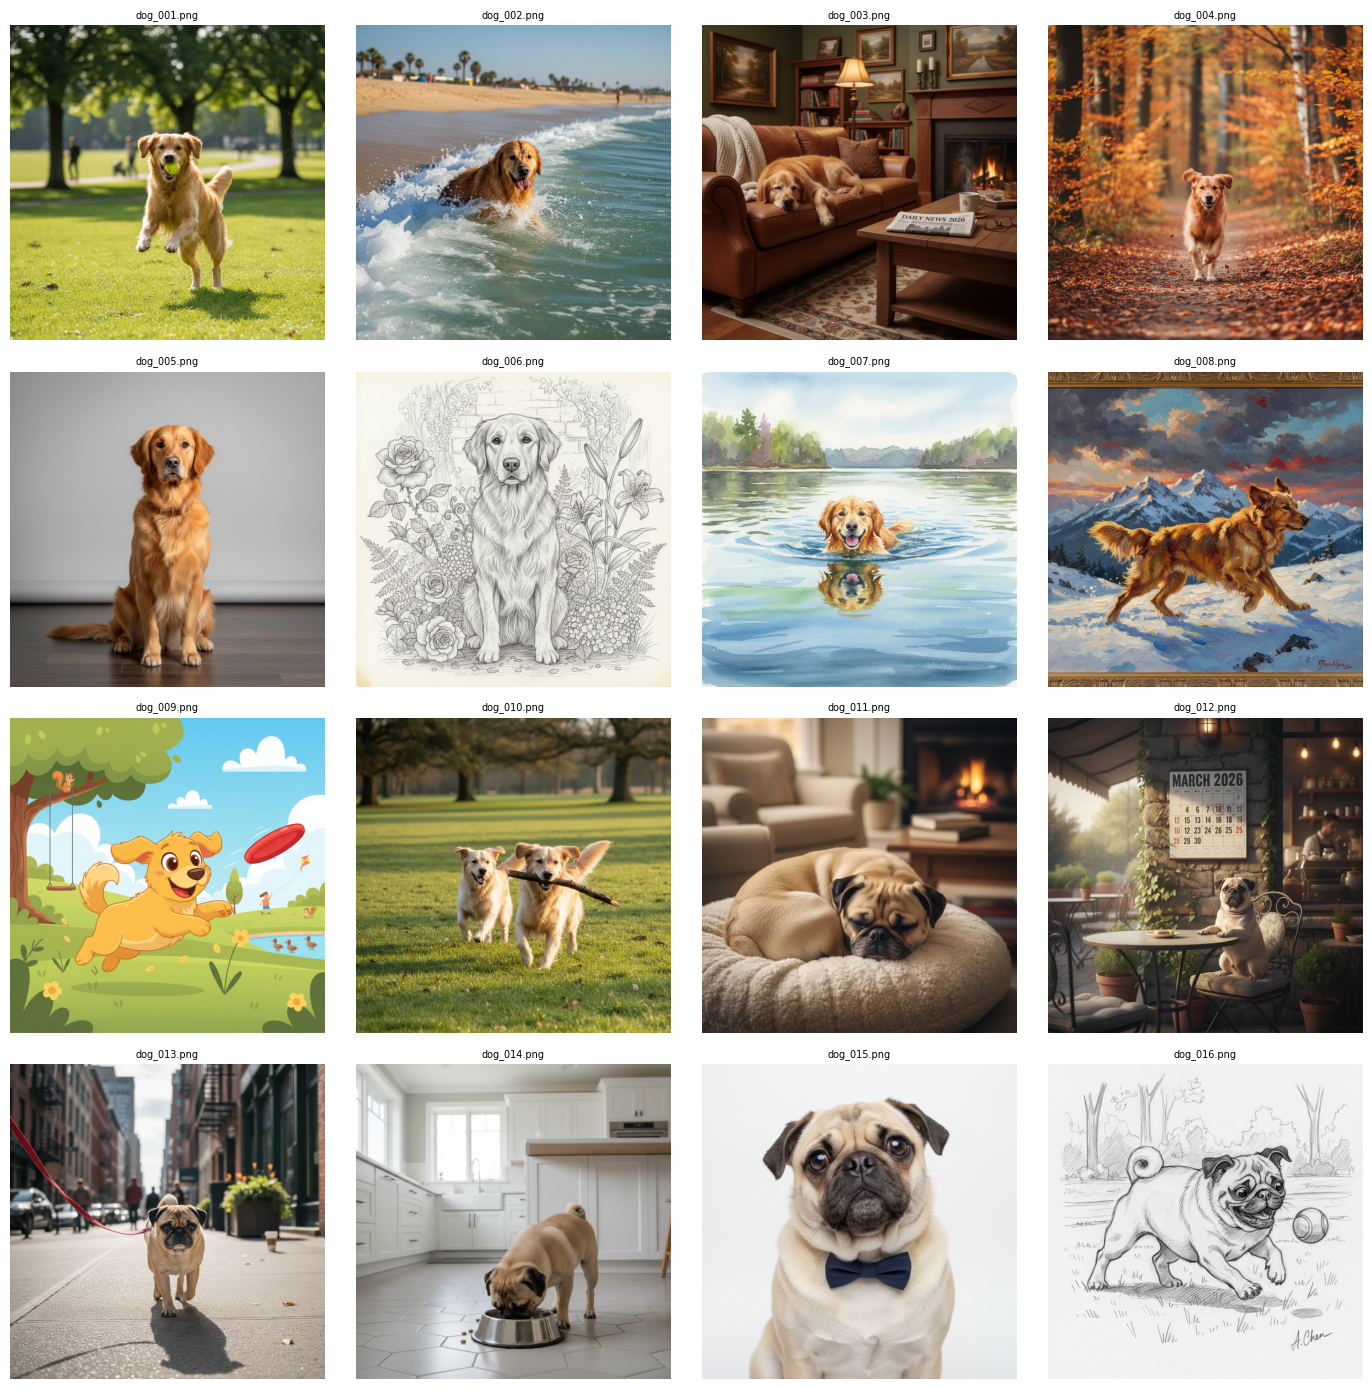

In [12]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

IMAGE_DIR = Path("data/dogs")

image_paths = sorted(list(IMAGE_DIR.glob("*.png")) + list(IMAGE_DIR.glob("*.jpg")))

print(f"Total images: {len(image_paths)}")
for p in image_paths[:10]:
    print(" ", p.name)

sample = image_paths[:16]

fig, axes = plt.subplots(4,4, figsize=(14,14))
for ax, img_path in zip(axes.flat, sample):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
from pathlib import Path

IMAGE_DIR = Path("data/dogs")

image_paths = sorted(
    list(IMAGE_DIR.glob("*.png")) +
    list(IMAGE_DIR.glob("*.jpg")) +
    list(IMAGE_DIR.glob("*.jpeg"))
)

print("IMAGE_DIR exists?", IMAGE_DIR.exists())
print("Total images found:", len(image_paths))
print("First 5:", [p.name for p in image_paths[:5]])

assert len(image_paths) > 0, f"No images found in {IMAGE_DIR.resolve()}"

IMAGE_DIR exists? True
Total images found: 100
First 5: ['dog_001.png', 'dog_002.png', 'dog_003.png', 'dog_004.png', 'dog_005.png']


## 2. The Task

Your goal is to build a **searchable index** over these dog images that allows us to find relevant images using natural language queries, metadata filters, or both.

There are broadly two approaches:

**Approach A: Text-based pipeline**
1. Use a vision LLM to generate text descriptions of each image
2. Extract structured metadata (breed, style, setting, etc.) using an LLM with structured output
3. Embed the descriptions and build a searchable index (e.g., using LanceDB)
4. Search using semantic similarity over text + metadata filters

**Approach B: Multimodal embeddings**
1. Use a multimodal embedding model to embed the images directly
2. Embed text queries in the same space
3. Search by comparing query embeddings to image embeddings

You may combine both approaches or use a different method entirely. Use any tools from the course — `litellm`, `lancedb`, `pydantic`, `sentence-transformers` - or any other tools you want.


In [15]:
import os
import json
import base64
import time
import pandas as pd
from pathlib import Path
import litellm

TEMP_DIR = Path("temp")
TEMP_DIR.mkdir(exist_ok=True)
METADATA_FILE = TEMP_DIR / "metadata.csv"

def encode_image_base64(path: Path) -> str:
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def describe_image(img_path: Path) -> dict:
    b64 = encode_image_base64(img_path)
    
    prompt = """Analyze this dog image and return ONLY a valid JSON object with these exact keys:
- description: 2-3 sentence description of the image
- breed: primary dog breed, use 'mixed' or 'unknown' if unclear
- style: one of photograph, pencil_sketch, watercolor, cartoon, oil_painting, digital_art, other
- setting: one of beach, park, living_room, snow, forest, cafe, city, studio, other
- activity: one of sitting, running, eating, sleeping, playing, posing, other
- has_text: true or false
- mood: one of happy, calm, playful, serious, sad, other

Return ONLY the JSON. No markdown, no extra text."""

    response = litellm.completion(
        model="gpt-4o-mini",
        messages=[{
            "role": "user",
            "content": [
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64}"}},
                {"type": "text", "text": prompt}
            ]
        }],
        max_tokens=400
    )
    
    data = json.loads(response.choices[0].message.content.strip())
    data["filename"] = img_path.name
    return data

test = describe_image(image_paths[0])
print(json.dumps(test, indent=2))

{
  "description": "A golden retriever is seen leaping joyfully in a park, holding a tennis ball in its mouth. Sunlight filters through the trees, creating a lively and vibrant atmosphere.",
  "breed": "golden_retriever",
  "style": "photograph",
  "setting": "park",
  "activity": "running",
  "has_text": false,
  "mood": "playful",
  "filename": "dog_001.png"
}


In [17]:
import pandas as pd
import time
from pathlib import Path
from pandas.errors import EmptyDataError

# paths
TEMP_DIR = Path("temp")
TEMP_DIR.mkdir(exist_ok=True)
METADATA_FILE = TEMP_DIR / "metadata.csv"

# ---- robust cache load ----
existing_df = pd.DataFrame()
processed_files = set()

if METADATA_FILE.exists() and METADATA_FILE.stat().st_size > 0:
    try:
        existing_df = pd.read_csv(METADATA_FILE)

        if "filename" in existing_df.columns:
            processed_files = set(existing_df["filename"].astype(str).tolist())
            print(f"Found {len(existing_df)} cached records")
        else:
            # file has content but not the expected schema
            print("metadata.csv exists but has no 'filename' column. Starting fresh.")
            existing_df = pd.DataFrame()
            processed_files = set()

    except EmptyDataError:
        print("metadata.csv exists but is empty. Starting fresh.")
        existing_df = pd.DataFrame()
        processed_files = set()
else:
    if METADATA_FILE.exists():
        print("metadata.csv exists but is empty (0 bytes). Starting fresh.")
    else:
        print("No metadata.csv found. Starting fresh.")

to_process = [p for p in image_paths if p.name not in processed_files]
print(f"Images to process: {len(to_process)}")

new_records = []
for i, img_path in enumerate(to_process):
    try:
        record = describe_image(img_path)   # your function
        new_records.append(record)
        print(f"  {i+1}/{len(to_process)}: {img_path.name}")
        time.sleep(0.3)
    except Exception as e:
        print(f"  ERROR on {img_path.name}: {e}")

if new_records:
    new_df = pd.DataFrame(new_records)

    # ensure consistent columns even if existing_df empty
    if existing_df.empty:
        metadata_df = new_df
    else:
        metadata_df = pd.concat([existing_df, new_df], ignore_index=True)

    metadata_df.to_csv(METADATA_FILE, index=False)
else:
    metadata_df = existing_df

print("Final metadata rows:", len(metadata_df))
metadata_df.head()

metadata.csv exists but is empty. Starting fresh.
Images to process: 100
  1/100: dog_001.png
  2/100: dog_002.png
  3/100: dog_003.png
  4/100: dog_004.png
  5/100: dog_005.png
  6/100: dog_006.png
  7/100: dog_007.png
  8/100: dog_008.png
  9/100: dog_009.png
  10/100: dog_010.png
  11/100: dog_011.png
  12/100: dog_012.png
  13/100: dog_013.png
  14/100: dog_014.png
  15/100: dog_015.png
  16/100: dog_016.png
  17/100: dog_017.png
  18/100: dog_018.png
  19/100: dog_019.png
  20/100: dog_020.png
  21/100: dog_021.png
  22/100: dog_022.png
  23/100: dog_023.png
  24/100: dog_024.png
  25/100: dog_025.png
  26/100: dog_026.png
  27/100: dog_027.png
  28/100: dog_028.png
  29/100: dog_029.png
  30/100: dog_030.png
  31/100: dog_031.png
  32/100: dog_032.png
  33/100: dog_033.png
  34/100: dog_034.png
  35/100: dog_035.png
  36/100: dog_036.png
  37/100: dog_037.png
  38/100: dog_038.png
  39/100: dog_039.png
  40/100: dog_040.png
  41/100: dog_041.png
  42/100: dog_042.png
  43/100: do

,description,breed,style,setting,activity,has_text,mood,filename
0,"A golden retriever is captured mid-air, jumpin...",golden_retriever,photograph,park,playing,False,playful,dog_001.png
1,The image shows a golden retriever playfully s...,golden_retriever,photograph,beach,playing,False,happy,dog_002.png
2,The image showcases a serene living room setti...,retriever,photograph,living_room,sleeping,True,calm,dog_003.png
3,The image captures a golden retriever happily ...,golden_retriever,photograph,forest,running,False,happy,dog_004.png
4,The image features a golden retriever sitting ...,golden_retriever,photograph,studio,sitting,False,calm,dog_005.png


In [18]:
from sentence_transformers import SentenceTransformer
import lancedb
import pandas as pd
import numpy as np
from pathlib import Path

# Load metadata
METADATA_FILE = Path("temp") / "metadata.csv"
metadata_df = pd.read_csv(METADATA_FILE)

# Create text model
text_model = SentenceTransformer("all-MiniLM-L6-v2")

# Create embeddings if missing
if "vector" not in metadata_df.columns:
    texts = metadata_df["description"].fillna("").astype(str).tolist()
    vectors = text_model.encode(texts, normalize_embeddings=True, show_progress_bar=True)
    metadata_df["vector"] = list(np.asarray(vectors, dtype=np.float32))

# Build or load LanceDB table
db = lancedb.connect("lancedb_dogs")
table_name = "dogs_text"

if table_name in db.table_names():
    table = db.open_table(table_name)
else:
    table = db.create_table(table_name, data=metadata_df.to_dict(orient="records"), mode="overwrite")

print("Setup complete")

/Users/purtilalan/ai-engineering-fordham/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1887.10it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 4/4 [00:00<00:00,  5.29it/s]
/var/folders/19/_4smmlxd5b36j0s3l01h26rw0000gn/T/ipykernel_5463/2403196206.py:24: DeprecationWarning: table_names() is deprecated, use list_tables() instead
  if table_name in db.table_names():


Setup complete


[2026-03-04T02:47:33Z WARN  lance::dataset::write::insert] No existing dataset at /Users/purtilalan/ai-engineering-fordham/lancedb_dogs/dogs_text.lance, it will be created


In [19]:
def query_index(query: str, filter: str = None, k: int = 5):
    q_vec = text_model.encode([query], normalize_embeddings=True)[0].tolist()
    q = table.search(q_vec).limit(int(k))
    if filter is not None:
        q = q.where(filter, prefilter=True)
    results = q.to_list()
    return [
        {
            "filename": r["filename"],
            "breed": r["breed"],
            "style": r["style"],
            "setting": r["setting"],
            "activity": r["activity"],
            "mood": r["mood"],
            "score": round(1 - r["_distance"], 4)
        }
        for r in results
    ]

## 3. Your Own Queries

To make a good search system, you will need to come up with some of your own queries and "golden" answers to these queries to evaluate your system with. Show us your work.

In [20]:
my_queries = [
    {
        "query": "a dog playing in the park",
        "filter": None,
        "k": 10,
        "gold": ["dog_001.png"]
    },
    {
        "query": "a dog swimming at the beach",
        "filter": None,
        "k": 10,
        "gold": ["dog_002.png"]
    },
    {
        "query": "a dog in a pencil sketch",
        "filter": "style = 'pencil_sketch'",
        "k": 10,
        "gold": ["dog_006.png"]
    }
]

In [21]:
hits = 0

for item in my_queries:
    results = query_index(item["query"], filter=item["filter"], k=item["k"])
    returned = [r["filename"] for r in results]

    hit = any(g in returned for g in item["gold"])
    hits += int(hit)

    print("\nQUERY:", item["query"])
    print("FILTER:", item["filter"])
    print("GOLD:", item["gold"])
    print("RETURNED:", returned)
    print("HIT GOLD?:", hit)

print("\nTotal:", hits, "/", len(my_queries), "hits")


QUERY: a dog playing in the park
FILTER: None
GOLD: ['dog_001.png']
RETURNED: ['dog_062.png', 'dog_092.png', 'dog_029.png', 'dog_009.png', 'dog_001.png', 'dog_033.png', 'dog_072.png', 'dog_016.png', 'dog_099.png', 'dog_022.png']
HIT GOLD?: True

QUERY: a dog swimming at the beach
FILTER: None
GOLD: ['dog_002.png']
RETURNED: ['dog_034.png', 'dog_002.png', 'dog_007.png', 'dog_084.png', 'dog_027.png', 'dog_077.png', 'dog_096.png', 'dog_057.png', 'dog_035.png', 'dog_055.png']
HIT GOLD?: True

QUERY: a dog in a pencil sketch
FILTER: style = 'pencil_sketch'
GOLD: ['dog_006.png']
RETURNED: ['dog_026.png', 'dog_066.png', 'dog_096.png', 'dog_046.png', 'dog_056.png', 'dog_036.png', 'dog_086.png', 'dog_006.png', 'dog_016.png', 'dog_076.png']
HIT GOLD?: True

Total: 3 / 3 hits


In [22]:
accuracy = hits / len(my_queries)
print(f"Accuracy@{my_queries[0]['k']} = {hits}/{len(my_queries)} = {accuracy:.2f}")

Accuracy@10 = 3/3 = 1.00


## 4. Evaluation Queries

We will evaluate your index by running queries against it — queries similar in spirit to the examples below, but not identical.

**Important:** Define a function called `query_index(query, filter=None, k=5)` that takes a natural language query, an optional metadata filter string (e.g., `"breed = 'pug'"`), and returns the top-k results as a list of dicts with at least a `"filename"` key. We will call this function to test your system.

Filter strings use SQL `WHERE` clause syntax (which LanceDB supports natively), e.g., `"breed = 'pug'"`, `"style = 'cartoon'"`, `"has_text = true"`.

### Example semantic queries
```python
query_index("a happy dog at the beach", k=5)
query_index("a dog sitting in a cafe", k=5)
query_index("a pencil drawing of a dog", k=5)
```

### Example filtered queries
```python
query_index("dog", filter="breed = 'corgi'", k=20)
query_index("dog", filter="style = 'cartoon'", k=20)
query_index("dog", filter="setting = 'living_room'", k=20)
query_index("dog", filter="activity = 'eating'", k=20)
```

### Example combined queries
```python
query_index("dog in the snow", filter="breed = 'husky'", k=5)
query_index("cute dog posing", filter="style = 'pencil_sketch'", k=5)
query_index("running on the beach", filter="breed = 'dalmatian'", k=5)
```

Run these example queries and display results clearly — filenames, metadata, and scores.

In [23]:
eval_queries = [
    # Example semantic queries
    ("a happy dog at the beach", None, 5),
    ("a dog sitting in a cafe", None, 5),
    ("a pencil drawing of a dog", None, 5),

    # Example filtered queries
    ("dog", "breed = 'corgi'", 20),
    ("dog", "style = 'cartoon'", 10),
    ("dog", "setting = 'living_room'", 10),
    ("dog", "activity = 'eating'", 10),

    # Example combined queries
    ("dog in the snow", "breed = 'husky'", 5),
    ("cute dog posing", "style = 'pencil_sketch'", 5),
    ("running on the beach", "breed = 'dalmatian'", 5),
]

for query, filt, k in eval_queries:
    print("\n==============================")
    print("QUERY:", query)
    print("FILTER:", filt)

    results = query_index(query, filter=filt, k=k)

    for r in results:
        print({
            "filename": r["filename"],
            "breed": r.get("breed"),
            "style": r.get("style"),
            "setting": r.get("setting"),
            "activity": r.get("activity")
        })


QUERY: a happy dog at the beach
FILTER: None
{'filename': 'dog_034.png', 'breed': 'unknown', 'style': 'photograph', 'setting': 'beach', 'activity': 'running'}
{'filename': 'dog_002.png', 'breed': 'golden_retriever', 'style': 'photograph', 'setting': 'beach', 'activity': 'playing'}
{'filename': 'dog_084.png', 'breed': 'beagle', 'style': 'photograph', 'setting': 'beach', 'activity': 'running'}
{'filename': 'dog_027.png', 'breed': 'German Shepherd', 'style': 'watercolor', 'setting': 'beach', 'activity': 'running'}
{'filename': 'dog_096.png', 'breed': 'poodle', 'style': 'pencil_sketch', 'setting': 'beach', 'activity': 'posing'}

QUERY: a dog sitting in a cafe
FILTER: None
{'filename': 'dog_063.png', 'breed': 'bulldog', 'style': 'photograph', 'setting': 'cafe', 'activity': 'sitting'}
{'filename': 'dog_078.png', 'breed': 'Shiba Inu', 'style': 'digital_art', 'setting': 'cafe', 'activity': 'sitting'}
{'filename': 'dog_062.png', 'breed': 'bulldog', 'style': 'photograph', 'setting': 'park', 'ac

In [24]:
import pandas as pd

def pretty_print_results(query, filt, results, max_rows=20):
    rows = []
    for r in results:
        rows.append({
            "filename": r.get("filename"),
            "breed": r.get("breed"),
            "style": r.get("style"),
            "setting": r.get("setting"),
            "activity": r.get("activity"),
        })
    df = pd.DataFrame(rows)
    print("\n==============================")
    print("QUERY:", query)
    print("FILTER:", filt)
    display(df.head(max_rows) if len(df) else df)

for query, filt, k in eval_queries:
    results = query_index(query, filter=filt, k=k)
    pretty_print_results(query, filt, results, max_rows=30)


QUERY: a happy dog at the beach
FILTER: None


,filename,breed,style,setting,activity
0,dog_034.png,unknown,photograph,beach,running
1,dog_002.png,golden_retriever,photograph,beach,playing
2,dog_084.png,beagle,photograph,beach,running
3,dog_027.png,German Shepherd,watercolor,beach,running
4,dog_096.png,poodle,pencil_sketch,beach,posing



QUERY: a dog sitting in a cafe
FILTER: None


,filename,breed,style,setting,activity
0,dog_063.png,bulldog,photograph,cafe,sitting
1,dog_078.png,Shiba Inu,digital_art,cafe,sitting
2,dog_062.png,bulldog,photograph,park,sitting
3,dog_069.png,bulldog,cartoon,living_room,eating
4,dog_044.png,corgi,photograph,cafe,sitting



QUERY: a pencil drawing of a dog
FILTER: None


...

""



QUERY: cute dog posing
FILTER: style = 'pencil_sketch'


,filename,breed,style,setting,activity
0,dog_026.png,German Shepherd,pencil_sketch,other,posing
1,dog_066.png,bulldog,pencil_sketch,other,posing
2,dog_096.png,poodle,pencil_sketch,beach,posing
3,dog_086.png,beagle,pencil_sketch,forest,sitting
4,dog_006.png,unknown,pencil_sketch,other,sitting



QUERY: running on the beach
FILTER: breed = 'dalmatian'


,filename,breed,style,setting,activity
0,dog_057.png,dalmatian,watercolor,beach,walking


## 5. Submission

- [ ] Create a new branch called `homework-6`
- [ ] Commit and push your work (notebook + CSV files in `temp/`)
- [ ] Create a Pull Request
- [ ] Merge the PR to main
- [ ] Submit the `.ipynb` file on Blackboard

**Note:** Commit the notebook and the `temp/` files that your code created. The `temp/` directory is gitignored by default, so you will need to force-add it: `git add -f temp/`.